<a href="https://colab.research.google.com/github/diyasonly19/northstar_database/blob/main/R_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("ggplot2",   quiet = TRUE)
install.packages("dplyr",     quiet = TRUE)
install.packages("tidyr",     quiet = TRUE)
install.packages("corrplot",  quiet = TRUE)

In [ ]:
library(ggplot2)
library(dplyr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Loading datasets directly from GitHub repository

BASE_URL <- "https://raw.githubusercontent.com/diyasonly19/northstar_database/main/northstar_dataset/"

orders <- read.csv(paste0(BASE_URL, "orders.csv"))
deliveries <- read.csv(paste0(BASE_URL, "deliveries.csv"))
customers <- read.csv(paste0(BASE_URL, "customers.csv"))
drivers <- read.csv(paste0(BASE_URL, "drivers.csv"))
vehicles <- read.csv(paste0(BASE_URL, "vehicles.csv"))
complaints <- read.csv(paste0(BASE_URL, "complaints.csv"))
incidents <- read.csv(paste0(BASE_URL, "incidents.csv"))
hubs <- read.csv(paste0(BASE_URL, "hubs.csv"))

cat("All datasets loaded successfully!\n")

All datasets loaded successfully!


In [ ]:
# Standardising all zone values to uppercase
orders$pickup_zone      <- toupper(trimws(orders$pickup_zone))
orders$dropoff_zone     <- toupper(trimws(orders$dropoff_zone))
drivers$base_zone       <- toupper(trimws(drivers$base_zone))
vehicles$assigned_zone  <- toupper(trimws(vehicles$assigned_zone))
customers$home_zone     <- toupper(trimws(customers$home_zone))

cat("Zone inconsistencies fixed\n")
print(orders$pickup_zone)

Zone inconsistencies fixed
   [1] "AIRPORT"   "NORTH"     "WEST"      "RIVERSIDE" "RIVERSIDE" "CENTRAL"  
   [7] "CENTRAL"   "RIVERSIDE" "NORTH"     "SOUTH"     "WEST"      "EAST"     
  [13] "AIRPORT"   "CTR"       "SOUTH"     "CENTRAL"   "AIRPORT"   "NORTH"    
  [19] "NORTH"     "WEST"      "WEST"      "RIVERSIDE" "NORTH"     "SOUTH"    
  [25] "NORTH"     "EAST"      "RIVERSIDE" "NORTH"     "EAST"      "NORTH"    
  [31] "EAST"      "CENTRAL"   "NORTH"     "NORTH"     "NORTH"     "RIVERSIDE"
  [37] "EAST"      "RIVERSIDE" "EAST"      "NORTH"     "RIVERSIDE" "RIVERSIDE"
  [43] "EAST"      "WEST"      "SOUTH"     "NORTH"     "WEST"      "RIVERSIDE"
  [49] "WEST"      "NORTH"     "AIRPORT"   "NORTH"     "EAST"      "NORTH"    
  [55] "AIRPORT"   "SOUTH"     "EAST"      "SOUTH"     "CENTRAL"   "NORTH"    
  [61] "AIRPORT"   "WEST"      "SOUTH"     "CENTRAL"   "SOUTH"     "SOUTH"    
  [67] "WEST"      "RIVERSIDE" "AIRPORT"   "CTR"       "NORTH"     "WEST"     
  [73] "CTR"       "RIVER

In [ ]:
# TASK 1: Creating Derived columns
# I created new meaningful columns from existing data
# This is called feature engineering that is  turning raw data into useful metrics

# Adding a profit margin column to orders joined with deliveries
orders_deliveries <- merge(orders, deliveries, by = "order_id")

# Creating a net_profit column (revenue minus cost)
orders_deliveries$net_profit <- orders_deliveries$order_value -
                                 orders_deliveries$fuel_or_charge_cost

# Creating a binary column: 1 if delivery was on time, 0 if not
orders_deliveries$is_ontime <- ifelse(
  orders_deliveries$delivery_status == "OnTime", 1, 0
)

# Creating a high value order flag (orders above the mean value)
mean_value <- mean(orders_deliveries$order_value)
orders_deliveries$high_value_order <- ifelse(
  orders_deliveries$order_value > mean_value, "High", "Low"
)

cat("New columns created:\n")
cat("- net_profit: revenue minus fuel/charge cost\n")
cat("- is_ontime: 1 = on time, 0 = delayed or failed\n")
cat("- high_value_order: High/Low based on mean order value of £",
    round(mean_value, 2), "\n")
head(orders_deliveries[, c("order_id", "order_value",
                            "fuel_or_charge_cost", "net_profit",
                            "delivery_status", "is_ontime",
                            "high_value_order")])

New columns created:
- net_profit: revenue minus fuel/charge cost
- is_ontime: 1 = on time, 0 = delayed or failed
- high_value_order: High/Low based on mean order value of £ 91.86 


,order_id,order_value,fuel_or_charge_cost,net_profit,delivery_status,is_ontime,high_value_order
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,O00001,126.65,15.82,110.83,OnTime,1,High
2,O00003,33.50,13.16,20.34,Delayed,0,Low
3,O00004,10.04,13.41,-3.37,OnTime,1,Low
4,O00005,125.58,13.53,112.05,OnTime,1,High
5,O00007,76.12,9.76,66.36,Delayed,0,Low
6,O00008,35.06,12.87,22.19,OnTime,1,Low


In [ ]:
# TASK 2: Aggregation using DPLYR
# dplyr is R's most powerful data manipulation package
# The %>% symbol means "then do this next" (called a pipe)

# Summarise delivery performance by service type
service_summary <- orders_deliveries %>%
  group_by(service_type) %>%
  summarise(
    total_orders      = n(),
    avg_order_value   = round(mean(order_value), 2),
    avg_net_profit    = round(mean(net_profit), 2),
    ontime_rate_pct   = round(mean(is_ontime) * 100, 1),
    avg_distance_km   = round(mean(route_distance_km), 2),
    avg_rating        = round(mean(customer_rating_post_delivery,
                                   na.rm = TRUE), 2)
  ) %>%
  arrange(desc(avg_net_profit))

print(service_summary)


# A tibble: 5 × 7
  service_type total_orders avg_order_value avg_net_profit ontime_rate_pct
  <chr>               <int>           <dbl>          <dbl>           <dbl>
1 Passenger             262            97.2           84.8            65.3
2 Business              126            97.4           84.3            57.9
3 Parcel                230            90.2           77.1            67.8
4 Retail                224            86.8           73.8            65.2
5 Medical               108            86.5           73.8            64.8
# ℹ 2 more variables: avg_distance_km <dbl>, avg_rating <dbl>


In [ ]:
#TASK 3: Filtering and reshaping data

# Filter 1: Extract only complaints that are both:
# 1. High severity
# 2. Still open and unresolved
high_severity_open <- complaints %>%

  # Keep only rows where severity is High
  # and complaint status is Open
  filter(severity == "High", status == "Open") %>%

  # Select only the most important columns for analysis
  select(complaint_id, customer_id, complaint_type,
         resolution_days, compensation_amount) %>%

  # Arrange complaints from highest to lowest compensation amount
  arrange(desc(compensation_amount))

# Display total number of matching complaints
cat("High severity open complaints:", nrow(high_severity_open), "\n")

# Show first 10 records
print(head(high_severity_open, 10))


# Filter 2: Identify drivers who may need additional support/training
# Conditions:
# - Driver rating is below the overall average
# - Driver has less than 3 years of experience

# Calculate the average driver rating first
avg_rating <- mean(drivers$driver_rating, na.rm = TRUE)

underperforming <- drivers %>%

  # Filter drivers based on rating and experience conditions
  filter(driver_rating < avg_rating, years_experience < 3) %>%

  # Select relevant columns for evaluation
  select(driver_id, base_zone, driver_rating,
         years_experience, training_score) %>%

  # Sort drivers from lowest to highest rating
  arrange(driver_rating)

# Display total number of underperforming drivers
cat("\nUnderperforming drivers (low rating + low experience):",
    nrow(underperforming), "\n")

# Print the filtered dataset
print(underperforming)

High severity open complaints: 14 
   complaint_id customer_id  complaint_type resolution_days compensation_amount
1        CP0283       C0252 DriverBehaviour              11               61.11
2        CP0261       C0566        AppIssue              18               47.09
3        CP0161       C0107         Billing               9               46.94
4        CP0294       C0339        AppIssue              19               39.64
5        CP0266       C0544          Damage              15               38.90
6        CP0133       C0480           Delay              15               38.76
7        CP0147       C0383 DriverBehaviour              15               33.52
8        CP0195       C0110           Delay               8               32.61
9        CP0131       C0583           Delay              14               32.48
10       CP0003       C0469           Delay              16               26.41

Underperforming drivers (low rating + low experience): 9 
  driver_id base_zone driv

In [ ]:
#TASK 4: MULTI-TABLE MERGE
# Combining 3 tables: deliveries + drivers + vehicles
# This is the R equivalent of SQL JOINs

delivery_detail <- deliveries %>%
  merge(drivers,  by = "driver_id",  all.x = TRUE) %>%
  merge(vehicles, by = "vehicle_id", all.x = TRUE)

# Now summarise: average rating by maintenance status
maintenance_performance <- delivery_detail %>%
  group_by(maintenance_status) %>%
  summarise(
    deliveries          = n(),
    avg_customer_rating = round(mean(customer_rating_post_delivery,
                                      na.rm = TRUE), 2),
    avg_distance        = round(mean(route_distance_km), 2),
    override_rate       = round(mean(manual_route_override_count), 2)
  ) %>%
  arrange(desc(avg_customer_rating))

cat(" Delivery Performance by Vehicle Maintenance Status \n")
print(maintenance_performance)

 Delivery Performance by Vehicle Maintenance Status 
# A tibble: 3 × 5
  maintenance_status deliveries avg_customer_rating avg_distance override_rate
  <chr>                   <int>               <dbl>        <dbl>         <dbl>
1 Active                    542                3.95         14.2          1.01
2 Scheduled                 154                3.93         13.5          0.94
3 InRepair                  254                3.63         13.5          0.9 


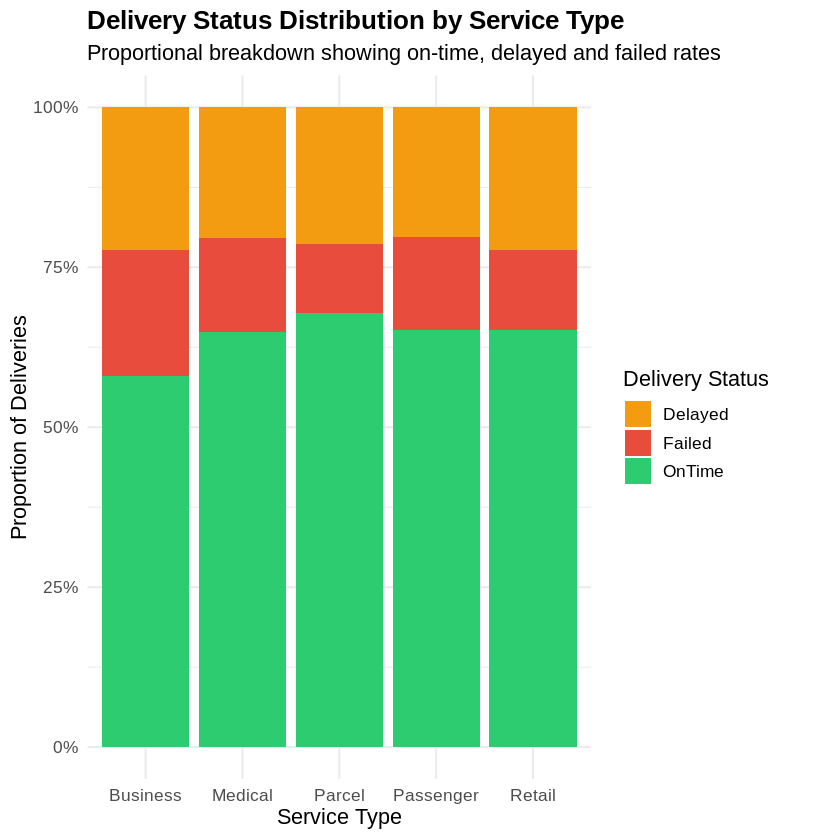

In [ ]:
# CHART 1: STACKED PROPORTIONAL BAR CHART
# ---------------------------------------------------------
# Purpose of this chart:
# This visualisation compares delivery outcomes across
# different service types such as Business, Medical,
# Parcel, Passenger, and Retail.
#
# A stacked proportional bar chart was chosen because:
# - Each service type has different order volumes
# - Using proportions makes comparison fairer
# - It helps identify which service type has higher
#   delayed or failed delivery percentages
# - It clearly shows the relationship between
#   successful and unsuccessful deliveries
# ---------------------------------------------------------


# Group the data by service type and delivery status
# Then count the number of deliveries in each category
status_by_service <- orders_deliveries %>%
  group_by(service_type, delivery_status) %>%

  # n() counts total rows in each grouped category
  summarise(count = n(), .groups = "drop")


# Create the chart
ggplot(status_by_service,

       # x-axis = service type
       # y-axis = delivery count
       # fill = delivery status colours
       aes(x = service_type, y = count, fill = delivery_status)) +

  # Create stacked bars
  # position = "fill" converts counts into proportions
  # so every bar adds up to 100%
  geom_bar(stat = "identity", position = "fill") +

  # Convert y-axis values into percentage format
  scale_y_continuous(labels = scales::percent) +

  # Manually assign colours for easier interpretation
  # Green  = successful deliveries
  # Orange = delayed deliveries
  # Red    = failed deliveries
  scale_fill_manual(values = c("OnTime"  = "#2ecc71",
                                "Delayed" = "#f39c12",
                                "Failed"  = "#e74c3c")) +

  # Add chart labels and titles
  labs(
    title    = "Delivery Status Distribution by Service Type",

    # Subtitle explains what the chart represents
    subtitle = "Proportional breakdown showing on-time, delayed and failed rates",

    x        = "Service Type",
    y        = "Proportion of Deliveries",
    fill     = "Delivery Status"
  ) +

  # Minimal theme gives a cleaner academic/report style
  theme_minimal(base_size = 13) +

  # Make the main title bold for better visibility
  theme(plot.title = element_text(face = "bold"))

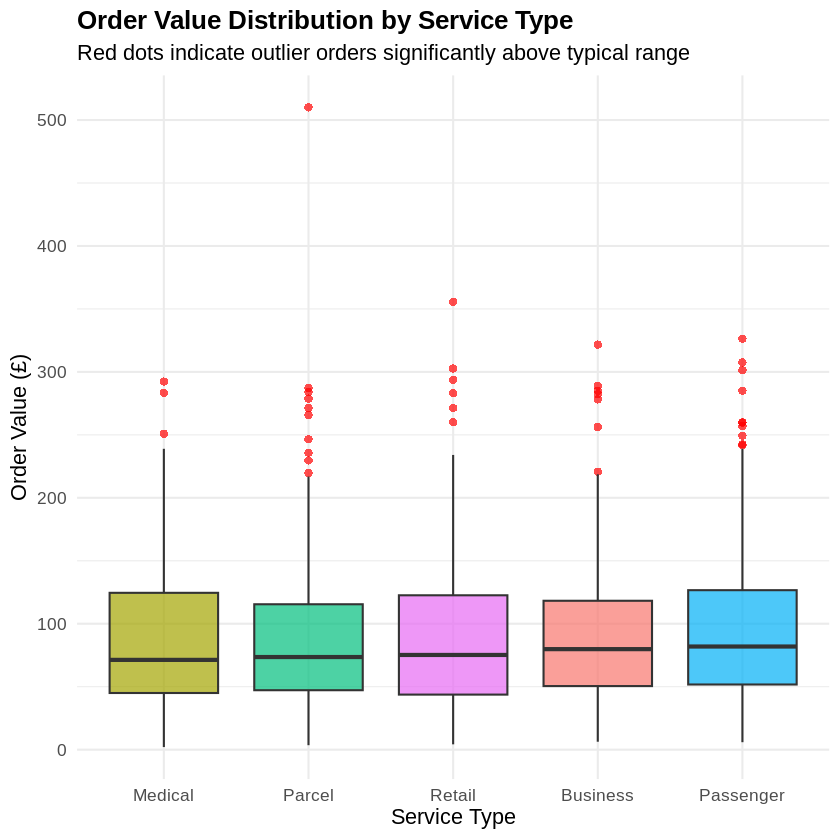

In [ ]:
# CHART 2: BOX PLOT
# ---------------------------------------------------------
# Purpose of this chart:
# This box plot is used to analyse how order values vary
# across different service types.
#
# A box plot was selected because it is very useful for:
# - Showing the median (middle value)
# - Displaying the spread of the data
# - Identifying unusually high or low orders (outliers)
# - Comparing variability between service categories
#
# This helps understand which services generate
# higher-value deliveries and which have more
# inconsistent pricing patterns.
# ---------------------------------------------------------


# Create box plot visualisation
ggplot(orders,

       # reorder() sorts service types based on median order value
       # This makes the chart easier to interpret visually
       aes(x = reorder(service_type, order_value, median),

           # y-axis shows order values in pounds
           y = order_value,

           # Different fill colours for each service type
           fill = service_type)) +

  # Create the box plot
  geom_boxplot(

    # Outliers are highlighted in red
    # These represent unusually expensive orders
    outlier.colour = "red",

    # Shape and size of outlier points
    outlier.shape  = 16,
    outlier.size   = 2,

    # Slight transparency improves readability
    alpha = 0.7
  ) +

  # Add titles and axis labels
  labs(
    title    = "Order Value Distribution by Service Type",

    # Subtitle explains meaning of red points
    subtitle = "Red dots indicate outlier orders significantly above typical range",

    x        = "Service Type",
    y        = "Order Value (£)",
    fill     = "Service Type"
  ) +

  # Minimal theme creates a cleaner report-style appearance
  theme_minimal(base_size = 13) +

  # Additional formatting
  theme(

    # Make title bold for emphasis
    plot.title  = element_text(face = "bold"),

    # Hide legend because service types are already shown on x-axis
    legend.position = "none"
  )



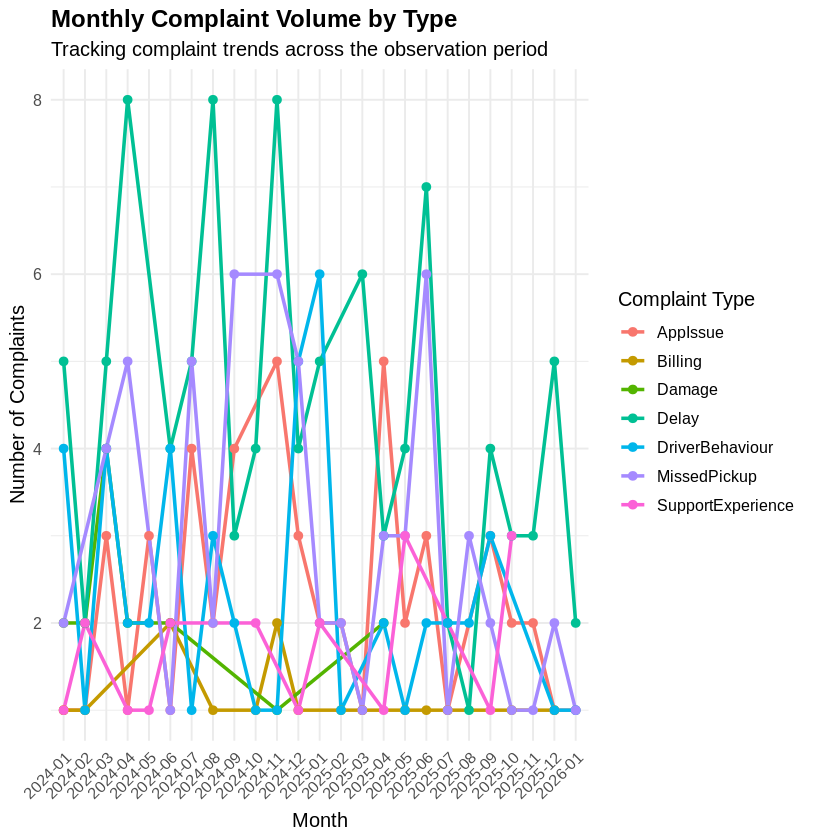

In [ ]:

# ── CHART 3: LINE CHART ────
# Shows how complaint volumes have changed over time
# Line charts are best for showing trends across a continuous axis

# Convert date and extract year-month
complaints$created_at <- as.POSIXct(complaints$created_at)
complaints$year_month <- format(complaints$created_at, "%Y-%m")

# Count complaints per month per type
complaints_over_time <- complaints %>%
  group_by(year_month, complaint_type) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(year_month)

ggplot(complaints_over_time,
       aes(x = year_month, y = count,
           colour = complaint_type, group = complaint_type)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title    = "Monthly Complaint Volume by Type",
    subtitle = "Tracking complaint trends across the observation period",
    x        = "Month",
    y        = "Number of Complaints",
    colour   = "Complaint Type"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title   = element_text(face = "bold"),
    axis.text.x  = element_text(angle = 45, hjust = 1)
  )

In [ ]:

# ── STATISTICAL ANALYSIS 1: CORRELATION ───────────────
# Purpose of this analysis:
# Correlation analysis is used to measure how strongly
# two numeric variables are related to each other.
#
# Correlation values range between:
# +1  = strong positive relationship
#  0  = no relationship
# -1  = strong negative relationship
#
# This analysis helps identify important business patterns,
# such as whether higher order values increase profit,
# or whether longer delivery distances increase fuel costs.
# ────────────────────────────────────────────────────


# Select only numeric columns needed for correlation analysis
numeric_data <- orders_deliveries %>%
  select(order_value, route_distance_km, fuel_or_charge_cost,
         customer_rating_post_delivery, manual_route_override_count,
         net_profit) %>%

  # Remove rows with missing values
  # Correlation requires complete numeric data
  na.omit()


# Generate correlation matrix
# cor() calculates relationships between all numeric variables
# round(..., 2) keeps values cleaner and easier to read
cor_matrix <- round(cor(numeric_data), 2)


# Print full correlation matrix
cat("=== CORRELATION MATRIX ===\n")
print(cor_matrix)


# Display selected important correlations separately
# This makes interpretation easier in the report
cat("\n=== KEY FINDINGS ===\n")


# Relationship between order value and profit
# Positive values suggest expensive orders generate more profit
cat("Order value vs net profit correlation:",
    cor_matrix["order_value", "net_profit"], "\n")


# Relationship between delivery distance and fuel cost
# Usually expected to be strongly positive
cat("Distance vs fuel cost correlation:",
    cor_matrix["route_distance_km", "fuel_or_charge_cost"], "\n")


# Relationship between customer rating and manual route changes
# Negative correlation may suggest route overrides reduce satisfaction
cat("Rating vs route overrides correlation:",
    cor_matrix["customer_rating_post_delivery",
               "manual_route_override_count"], "\n")

=== CORRELATION MATRIX ===
                              order_value route_distance_km fuel_or_charge_cost
order_value                          1.00              0.05               -0.04
route_distance_km                    0.05              1.00                0.53
fuel_or_charge_cost                 -0.04              0.53                1.00
customer_rating_post_delivery        0.00              0.03               -0.06
manual_route_override_count          0.00              0.20                0.10
net_profit                           1.00              0.01               -0.11
                              customer_rating_post_delivery
order_value                                            0.00
route_distance_km                                      0.03
fuel_or_charge_cost                                   -0.06
customer_rating_post_delivery                          1.00
manual_route_override_count                           -0.06
net_profit                                           

In [ ]:
# ── STATISTICAL ANALYSIS 2: ZONE PERFORMANCE STATISTICS ─────
# Purpose of this analysis:
# This section compares delivery performance across
# different pickup zones using descriptive statistics.
#
# Descriptive statistics help summarise large datasets
# into meaningful business insights.
#
# The analysis focuses on:
# - Total deliveries per zone
# - Average and median order values
# - Variability in order values
# - Customer satisfaction ratings
# - Failure percentages
# - Average net profit
#
# This helps identify which zones are performing well
# and which areas may require operational improvements.
# ────────────────────────────────────────────────────────────


# Group the dataset based on pickup zone
zone_stats <- orders_deliveries %>%
  group_by(pickup_zone) %>%

  # Generate summary statistics for each zone
  summarise(

    # Total number of deliveries completed in each zone
    total_deliveries  = n(),


    # Average order value
    # mean() calculates the arithmetic average
    mean_order_value  = round(mean(order_value), 2),


    # Median represents the middle value
    # Useful because it is less affected by extreme outliers
    median_order_value = round(median(order_value), 2),


    # Standard deviation measures variability/spread
    # Higher SD means order values vary more widely
    sd_order_value    = round(sd(order_value), 2),


    # Average customer rating after delivery
    # na.rm = TRUE ignores missing ratings
    mean_rating       = round(mean(customer_rating_post_delivery,
                                    na.rm = TRUE), 2),


    # Calculate failure percentage
    # TRUE values are treated as 1, FALSE as 0
    # Multiplying by 100 converts to percentage
    failed_pct        = round(mean(delivery_status == "Failed") * 100, 1),


    # Average net profit generated in each zone
    mean_net_profit   = round(mean(net_profit), 2)
  ) %>%

  # Arrange zones from highest to lowest failure percentage
  # Makes problem zones easier to identify
  arrange(desc(failed_pct))


# Display final statistical summary table
cat("=== ZONE PERFORMANCE STATISTICAL SUMMARY ===\n")
print(zone_stats)

=== ZONE PERFORMANCE STATISTICAL SUMMARY ===
# A tibble: 8 × 8
  pickup_zone total_deliveries mean_order_value median_order_value
  <chr>                  <int>            <dbl>              <dbl>
1 CENTRAL                  110             84.6               72.9
2 CTR                       64             93.4               83.2
3 NORTH                    135             90.2               78.9
4 RIVERSIDE                119             90.3               76.0
5 WEST                     114             89.0               70.7
6 EAST                     156             93.4               78.0
7 AIRPORT                  113            102.                82.0
8 SOUTH                    139             92.4               76.0
# ℹ 4 more variables: sd_order_value <dbl>, mean_rating <dbl>,
#   failed_pct <dbl>, mean_net_profit <dbl>


In [ ]:
# ── STATISTICAL ANALYSIS 3: T-TEST ──────────────────────────
# Purpose of this analysis:
# A t-test is used to compare the average values of two groups
# to determine whether the difference between them is
# statistically significant or simply caused by random chance.
#
# In this analysis, customer ratings are compared between:
# - High value orders
# - Low value orders
#
# The goal is to check whether expensive orders tend to
# receive different customer ratings compared to cheaper orders.
#
# Important interpretation:
# p-value < 0.05  → statistically significant difference
# p-value >= 0.05 → no statistically significant difference
# ────────────────────────────────────────────────────────────


# Extract customer ratings for HIGH value orders only
high_value_ratings <- orders_deliveries %>%

  # Keep only rows labelled as High value orders
  filter(high_value_order == "High") %>%

  # pull() extracts the rating column as a vector
  pull(customer_rating_post_delivery) %>%

  # Remove missing ratings
  na.omit()


# Extract customer ratings for LOW value orders only
low_value_ratings <- orders_deliveries %>%

  # Keep only rows labelled as Low value orders
  filter(high_value_order == "Low") %>%

  # Extract customer rating column
  pull(customer_rating_post_delivery) %>%

  # Remove missing values
  na.omit()


# Perform independent t-test
# This compares the average ratings of the two groups
t_result <- t.test(high_value_ratings, low_value_ratings)


# Print analysis heading
cat("=== T-TEST: High Value vs Low Value Order Ratings ===\n")


# Display average customer rating for high value orders
cat("High value orders - mean rating:",
    round(mean(high_value_ratings), 2), "\n")


# Display average customer rating for low value orders
cat("Low value orders  - mean rating:",
    round(mean(low_value_ratings), 2), "\n")


# Display p-value from the statistical test
# Rounded for cleaner report formatting
cat("p-value:", round(t_result$p.value, 4), "\n")


# Interpret the statistical result automatically
if(t_result$p.value < 0.05) {

  cat("Result: SIGNIFICANT difference — high value orders receive
      meaningfully different ratings\n")

} else {

  cat("Result: NO significant difference — order value does not
      predict customer rating\n")
}

=== T-TEST: High Value vs Low Value Order Ratings ===
High value orders - mean rating: 3.86 
Low value orders  - mean rating: 3.87 
p-value: 0.8033 
Result: NO significant difference — order value does not 
      predict customer rating
